In [184]:
!python nopants_train.py --nepoch 600 --save_path 'results/yolov3_07' --ctrl 50 --arch "yolov3" --seed_type variable --clamp_shift 0.01 --loss_type max_iou --seed_ratio 0.7 --device 'cuda'

Version 2.0
Train info: Namespace(device='cuda', lr=0.001, lr_seed=0.01, nepoch=600, checkpoints=0, batch_size=4, save_path='results/yolov3_07', alpha=10, tv_loss=0, lr_decay=2, lr_decay_seed=2, blur=1, like=1, ctrl=50.0, num_points_tshirt=60, num_points_trouser=60, arch='yolov3', cdist=0, seed_type='variable', rd_num=200, clamp_shift=0.01, resample_type=None, seed_temp=1.0, seed_opt='adam', tps2d_range_t=50.0, tps2d_range_r=0.1, tps3d_range=0.15, disable_tps2d=False, disable_tps3d=False, disable_test_tps2d=False, disable_test_tps3d=False, seed_ratio=0.7, loss_type='max_iou', test=False, test_iou=0.1, test_nms_thresh=1.0, test_mode='person', test_suffix='', train_iou=0.01, anneal=False, anneal_init=5.0, anneal_alpha=3.0)
One training epoch has 376 images
One test epoch has 130 images
/home/cynthia/miniforge3/envs/camo/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered in

In [ ]:
from nopants_train import *
import argparse
%load_ext autoreload
%autoreload 2

In [ ]:
parser = argparse.ArgumentParser(description='PyTorch Training')
parser.add_argument('--device', default='cuda:1', help='')
parser.add_argument('--lr', type=float, default=0.001, help='')
parser.add_argument('--lr_seed', type=float, default=0.01, help='')
parser.add_argument('--nepoch', type=int, default=600, help='')
parser.add_argument('--checkpoints', type=int, default=0, help='')
parser.add_argument('--batch_size', type=int, default=4, help='')
parser.add_argument('--save_path', default='results/', help='')
parser.add_argument("--alpha", type=float, default=10, help='')
parser.add_argument("--tv_loss", type=float, default=0, help='')
parser.add_argument("--lr_decay", type=float, default=2, help='')
parser.add_argument("--lr_decay_seed", type=float, default=2, help='')
parser.add_argument("--blur", type=float, default=1, help='')
parser.add_argument("--like", type=float, default=1, help='')
parser.add_argument("--ctrl", type=float, default=1, help='')
parser.add_argument("--num_points_tshirt", type=int, default=60, help='')
parser.add_argument("--num_points_trouser", type=int, default=60, help='')
parser.add_argument("--arch", type=str, default="rcnn")
parser.add_argument("--cdist", type=float, default=0, help='')
parser.add_argument("--seed_type", default='fixed', help='fixed, random, variable, langevin')
parser.add_argument("--rd_num", type=int, default=200, help='')
parser.add_argument("--clamp_shift", type=float, default=0, help='')
parser.add_argument("--resample_type", default=None, help='')
parser.add_argument("--seed_temp", type=float, default=1.0, help='')
parser.add_argument("--seed_opt", default='adam', help='')
parser.add_argument("--tps2d_range_t", type=float, default=50.0, help='')
parser.add_argument("--tps2d_range_r", type=float, default=0.1, help='')
parser.add_argument("--tps3d_range", type=float, default=0.15, help='')
parser.add_argument("--disable_tps2d", default=False, action='store_true', help='')
parser.add_argument("--disable_tps3d", default=False, action='store_true', help='')
parser.add_argument("--disable_test_tps2d", default=False, action='store_true', help='')
parser.add_argument("--disable_test_tps3d", default=False, action='store_true', help='')
parser.add_argument("--seed_ratio", default=1.0, type=float, help='The ratio of trainable part when seed type is variable')
parser.add_argument("--loss_type", default='max_iou', help='max_iou, max_conf, softplus_max, softplus_sum')
parser.add_argument("--test", default=False, action='store_true', help='')
parser.add_argument("--test_iou", type=float, default=0.1, help='')
parser.add_argument("--test_nms_thresh", type=float, default=1.0, help='')
parser.add_argument("--test_mode", default='person', help='person, all')
parser.add_argument("--test_suffix", default='', help='')
parser.add_argument("--train_iou", type=float, default=0.01, help='')
parser.add_argument("--anneal", default=False, action='store_true', help='')
parser.add_argument("--anneal_init", type=float, default=5.0, help='')
parser.add_argument("--anneal_alpha", type=float, default=3.0, help='')


args = parser.parse_args(args = "--nepoch 600 --save_path results/yolov3_07 --ctrl 50 --arch yolov3 --seed_type variable --clamp_shift 0.01 --loss_type max_iou --seed_ratio 0.7 --device cuda".split())
assert args.seed_type in ['fixed', 'random', 'variable', 'langevin']

torch.manual_seed(123)
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

print("Train info:", args)
trainer = PatchTrainer(args)
if not args.test:
    trainer.train()
else:
    epoch = args.checkpoints - 1
    trainer.load_weights(args.save_path, epoch)
    trainer.update_mesh(type='determinate')
    precision, recall, avg, confs, thetas = trainer.test(conf_thresh=0.01, iou_thresh=args.test_iou, angle_sample=37, use_tps2d=not args.disable_test_tps2d, use_tps3d=not args.disable_test_tps3d, mode=args.test_mode)
    info = [precision, recall, avg, confs]
    path = args.save_path + '/' + str(epoch) + 'test_results_tps'
    path = path + '_iou' + str(args.test_iou).replace('.', '') + '_' + args.test_mode + args.test_suffix
    path = path + '.npz'
    np.savez(path, thetas=thetas, info=info)

In [ ]:
trainer = PatchTrainer(args)
trainer.train()

# Voronoi pass

Used GPU:  <NVIDIA GeForce RTX 3090 Ti on Platform: NVIDIA CUDA (2 refs)>


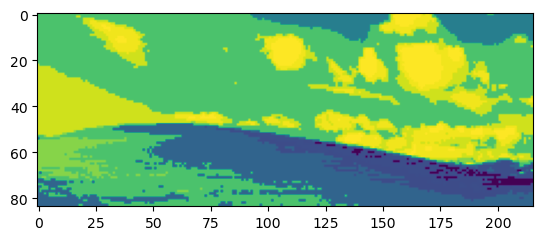

Number of objects in the image: 11.0


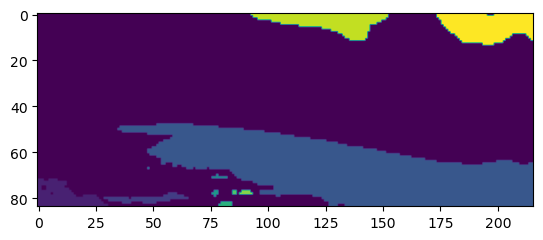

In [60]:
import pyclesperanto_prototype as cle
from skimage.io import imread, imsave
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
import numpy as np
# initialize / select GPU with "TX" in their name
device = cle.select_device("TX")
print("Used GPU: ", device)

im = imread("xp.png")
im = rgb2gray(im)
plt.imshow(im)
plt.pause(0.1)
plt.cla()

# process the image
inverted = cle.subtract_image_from_scalar(im, scalar=255)
blurred = cle.gaussian_blur(inverted, sigma_x=1, sigma_y=1)
binary = cle.threshold_otsu(blurred)
labeled = cle.connected_components_labeling_box(binary)

# The maximium intensity in a label image corresponds to the number of objects
num_labels = labeled.max()
print(f"Number of objects in the image: {num_labels}")

# save image to disc
plt.imshow(labeled)

In [32]:
from skimage.segmentation import slic
from skimage.segmentation import mark_boundaries
from skimage.util import img_as_float

he


/tmp/ipykernel_17835/1702379620.py:11: RuntimeWarning: Mean of empty slice.
  centroid_x.append(x.mean())
/tmp/ipykernel_17835/1702379620.py:12: RuntimeWarning: Mean of empty slice.
  centroid_y.append(y.mean())


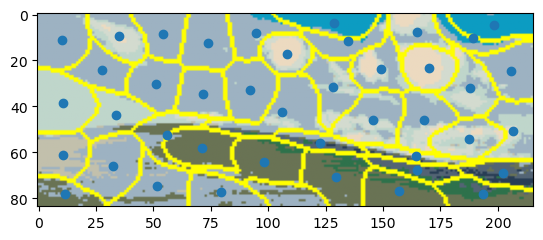

In [88]:
numSegments = 45
image = img_as_float(imread("xp.png"))
segments = slic(image, n_segments=numSegments, sigma=5, convert2lab=True)
x, y = get_centroids(segments)
# show the output of SLIC
fig = plt.figure("Superpixels -- %d segments" % (numSegments))
ax = fig.add_subplot(1, 1, 1)
ax.imshow(mark_boundaries(image, segments))
ax.scatter(y, x)

In [163]:
# # segments.max()
from collections import defaultdict
def get_centroids(segments, img):
    centroid_x, centroid_y = [], []
    med_colors = []
    clusters = []
    grey_img = rgb2gray(img)
    
    for i in range(1, segments.max()+1):
        mask = np.where(segments==i, False, True)
        mask = np.stack([mask,mask,mask], axis=2)
        coordinates = np.argwhere(mask==False)
        x = np.array(coordinates[:, 0])
        y = np.array(coordinates[:, 1])

        centroid_x.append(x.mean())
        centroid_y.append(y.mean())

        masked_section = np.ma.array(img, mask=mask)
        color_set = defaultdict(int)
        for x in masked_section:
            for y in x:
                if not isinstance(y[0], np.ma.MaskedArray):
                    color_set[(y[0],y[1],y[2])] += 1
            
        most_seen = None
        most_seen_times = 0
        rgb_color = None
        for color in color_set:
            if color_set[color] > most_seen_times:
                most_seen = color
                most_seen_times = color_set[color]
        
        med_colors.append(most_seen)
        # break

    return centroid_x, centroid_y, med_colors

{(0.9254901960784314, 0.8549019607843137, 0.7529411764705882), (0.3254901960784314, 0.39215686274509803, 0.4549019607843137), (0.047058823529411764, 0.611764705882353, 0.7607843137254902), (0.4156862745098039, 0.45098039215686275, 0.32941176470588235), (0.8274509803921568, 0.8588235294117647, 0.8117647058823529), (0.7490196078431373, 0.8392156862745098, 0.796078431372549), (0.1803921568627451, 0.44705882352941173, 0.29411764705882354), (0.615686274509804, 0.6980392156862745, 0.7607843137254902), (0.7607843137254902, 0.7529411764705882, 0.6745098039215687)}


In [166]:
x, y, colors = get_centroids(segments, image)

In [172]:
for color in set(colors):
    print([int(color[0]*255), int(color[1]*255), int(color[2]*255)])

[236, 218, 192]
[83, 100, 116]
[12, 156, 194]
[105, 115, 84]
[211, 219, 207]
[191, 214, 203]
[46, 113, 75]
[157, 178, 194]
[194, 192, 172]
